In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 64.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


## Local Inference on GPU
Model page: https://huggingface.co/HuggingFaceTB/SmolVLM-256M-Instruct

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/HuggingFaceTB/SmolVLM-256M-Instruct)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-text-to-text", model="HuggingFaceTB/SmolVLM-256M-Instruct")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
pipe(text=messages)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'input_text': [{'role': 'user',
    'content': [{'type': 'image',
      'url': 'https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG'},
     {'type': 'text', 'text': 'What animal is on the candy?'}]}],
  'generated_text': [{'role': 'user',
    'content': [{'type': 'image',
      'url': 'https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG'},
     {'type': 'text', 'text': 'What animal is on the candy?'}]},
   {'role': 'assistant', 'content': ' The candy has a turtle animal.'}]}]

In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForMultimodalLM

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
model = AutoModelForMultimodalLM.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
inputs = processor.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(processor.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

 The candy has a turtle animal.<end_of_utterance>


In [ ]:
!pip install -q qwen_vl_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 20.0 MB/s eta 0:00:00


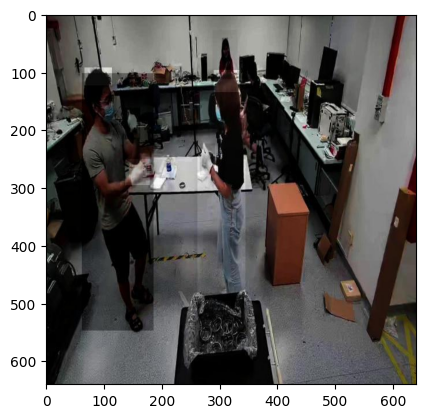

Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ:  3.


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import json
from pathlib import Path
import torch
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

TEST_IMAGE = Path("/content/-03-3-1-263_jpg.rf.fe68a6f407d74825f32c77be51e958e3.jpg")  # путь к картинке

image = cv2.imread(TEST_IMAGE)[:,:,::-1]
plt.imshow(image)
plt.show()

TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=256,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)


In [ ]:

PROMPT = """
Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!
"""

all_items = []

IMAGE_DIR = '/content'

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": PROMPT
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
 Объекты.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
 Степень.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
 Опиш изображение кратко и информативно.
Processing: -01-16-2-4-2-1-28_jpg.rf.ebeb8cf9d541d5af713ac4414162e366.jpg
 Boxes.
Processing: -01-16-2-4-2-1-43_jpg.rf.ff99aa037d9bfedd3db50d5fb33aec86.jpg
 Ответ: у вас у вас у вас.
Processing: -01-16-2-4-2-2-25_jpg.rf.1ba567b4c64d53342ed4dc1200fcfa2d.jpg
 Ответ: 1.
Processing: -01-16-2-4-2-2-33_jpg.rf.e314997ea7789b9c5f6124c04783d3a7.jpg
 Опиш изображение кратко и информативно.
Processing: -01-16-2-4-2-2-39_jpg.rf.ac94511f8a64fa635875cf11c54c79cb.jpg
 Ответ: Объекты и действия.
Processing: -01-16-2-4-2-2-42_jpg.rf.965ebc2c5db9acbde62cd8a098f88821.jpg
 Ответ: Одним предложением.
Processing: -01-16-2-4-2-3-49_jpg.rf.9ec054286ca8b5b376f1359b5fefbf97.jpg
 Ответ: Объект 1.
Processing: -01-16-2-4-2-4-20_jpg.rf.f

KeyboardInterrupt: 